# SPI Benchmark Analysis

Loads timing results from `scripts/benchmark_spis.py` and provides:
1. Per-SPI timing tables across (M, T) grid
2. Empirical complexity estimation: $t \sim a \cdot M^\alpha \cdot T^\beta$
3. Top-X slowest/fastest SPIs (total or per-family)
4. Family-level summaries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats

from src.utils import project_root

# Config
TIMINGS_PATH = project_root() / "data" / "benchmark" / "timings.json"
TOP_N = 20  # show top N slowest/fastest
FAMILY = None  # set to e.g. "basic", "spectral" to filter; None = all

In [2]:
# Load results
with open(TIMINGS_PATH) as f:
    raw = json.load(f)

# Build a tidy DataFrame: rows = (M, T, SPI), value = seconds
rows = []
for entry in raw["results"]:
    M, T = entry["M"], entry["T"]
    for spi_name, secs in entry["timings"].items():
        rows.append({"M": M, "T": T, "spi": spi_name, "seconds": secs})

df = pd.DataFrame(rows)
print(f"Loaded {len(raw['results'])} (M,T) combos, {df['spi'].nunique()} unique SPIs, {len(df)} rows total")
df.head(-5)

Loaded 25 (M,T) combos, 202 unique SPIs, 5050 rows total


,M,T,spi,seconds
0,3,100,cov_EmpiricalCovariance,0.002160
1,3,100,cov_EllipticEnvelope,0.007619
2,3,100,cov_GraphicalLasso,0.000906
3,3,100,cov_GraphicalLassoCV,0.016245
4,3,100,cov_LedoitWolf,0.000221
...,...,...,...,...
5040,32,2000,coint_aeg_tstat_trend-c_autolag-aic_maxlag-10,2.027538
5041,32,2000,coint_aeg_tstat_trend-ct_autolag-aic_maxlag-10,2.020578
5042,32,2000,coint_aeg_tstat_trend-ct_autolag-bic_maxlag-10,2.121762
5043,32,2000,pec,0.003700


In [3]:
# Family mapping: prefer the spi_families dict saved in the JSON (keyed by SPI identifier,
# value = module name e.g. "basic", "infotheory", "spectral").
# Falls back to "unknown" if the entry is missing (old JSON without the field).
spi_families: dict[str, str] = raw.get("spi_families", {})

def get_family(spi_name: str) -> str:
    return spi_families.get(spi_name, "unknown")

df["family"] = df["spi"].apply(get_family)
df["family"].value_counts()

family
unknown    5050
Name: count, dtype: int64

## Filter by family (optional)

In [4]:
dff = df if FAMILY is None else df[df["family"] == FAMILY]
print(f"Working with {dff['spi'].nunique()} SPIs" + (f" (family={FAMILY})" if FAMILY else " (all families)"))

Working with 202 SPIs (all families)


## Top-N slowest / fastest SPIs (by total time across all (M,T))

In [5]:
TOP_N=50
total_per_spi = dff.groupby("spi")["seconds"].sum().sort_values(ascending=False)
mean_per_spi = dff.groupby("spi")["seconds"].mean().sort_values(ascending=False)

summary = pd.DataFrame({
    "total_s": total_per_spi,
    "mean_s": mean_per_spi,
    "family": dff.groupby("spi")["family"].first(),
}).sort_values("mean_s", ascending=False)

print(f"=== Top {TOP_N} SLOWEST SPIs ===")
display(summary.head(TOP_N))

print(f"\n=== Top {TOP_N} FASTEST SPIs ===")
display(summary.tail(TOP_N).iloc[::-1])

=== Top 50 SLOWEST SPIs ===


,total_s,mean_s,family
spi,,,
te_kraskov_NN-4_DCE_k-max-10_tau-max-4,259.941497,10.397660,unknown
psi_multitaper_mean_fs-1_fmin-0_fmax-0-5,249.546890,9.981876,unknown
psi_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,223.508288,8.940332,unknown
te_kraskov_NN-4_DCE_k-1_kt-1_l-1_lt-1,176.340846,7.053634,unknown
te_kraskov_NN-4_DCE_k-2_kt-1_l-1_lt-1,170.270881,6.810835,unknown
psi_multitaper_mean_fs-1_fmin-0_fmax-0-25,167.803198,6.712128,unknown
cce_kernel_W-0.5,128.659577,5.146383,unknown
te_kraskov_NN-4_k-max-10_tau-max-4,116.601333,4.664053,unknown
cce_kozachenko,55.516170,2.220647,unknown



=== Top 50 FASTEST SPIs ===


,total_s,mean_s,family
spi,,,
prec-sq_GraphicalLasso,0.000638,0.000026,unknown
prec-sq_EllipticEnvelope,0.000641,0.000026,unknown
prec-sq_LedoitWolf,0.000656,0.000026,unknown
prec_EllipticEnvelope,0.000659,0.000026,unknown
prec-sq_ShrunkCovariance,0.000672,0.000027,unknown
cov-sq_OAS,0.000675,0.000027,unknown
prec-sq_MinCovDet,0.000688,0.000028,unknown
cov-sq_MinCovDet,0.000689,0.000028,unknown
cov-sq_ShrunkCovariance,0.000701,0.000028,unknown


## Per-family summary

In [6]:
fam_summary = dff.groupby("family").agg(
    n_spis=("spi", "nunique"),
    total_s=("seconds", "sum"),
    mean_per_spi_s=("seconds", "mean"),
    max_s=("seconds", "max"),
).sort_values("total_s", ascending=False)
fam_summary["pct"] = 100 * fam_summary["total_s"] / fam_summary["total_s"].sum()
display(fam_summary)

,n_spis,total_s,mean_per_spi_s,max_s,pct
family,,,,,
unknown,202,1972.27606,0.39055,241.412346,100.0


## Top-N slowest per family

In [7]:
for fam in sorted(dff["family"].unique()):
    sub = summary[summary["family"] == fam].head(5)
    if sub.empty:
        continue
    print(f"\n--- {fam} (top 5 slowest) ---")
    display(sub[["total_s", "mean_s"]])


--- unknown (top 5 slowest) ---


,total_s,mean_s
spi,,
te_kraskov_NN-4_DCE_k-max-10_tau-max-4,259.941497,10.397660
psi_multitaper_mean_fs-1_fmin-0_fmax-0-5,249.546890,9.981876
psi_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,223.508288,8.940332
te_kraskov_NN-4_DCE_k-1_kt-1_l-1_lt-1,176.340846,7.053634
te_kraskov_NN-4_DCE_k-2_kt-1_l-1_lt-1,170.270881,6.810835


## Timing heatmaps: SPI x (M, T)

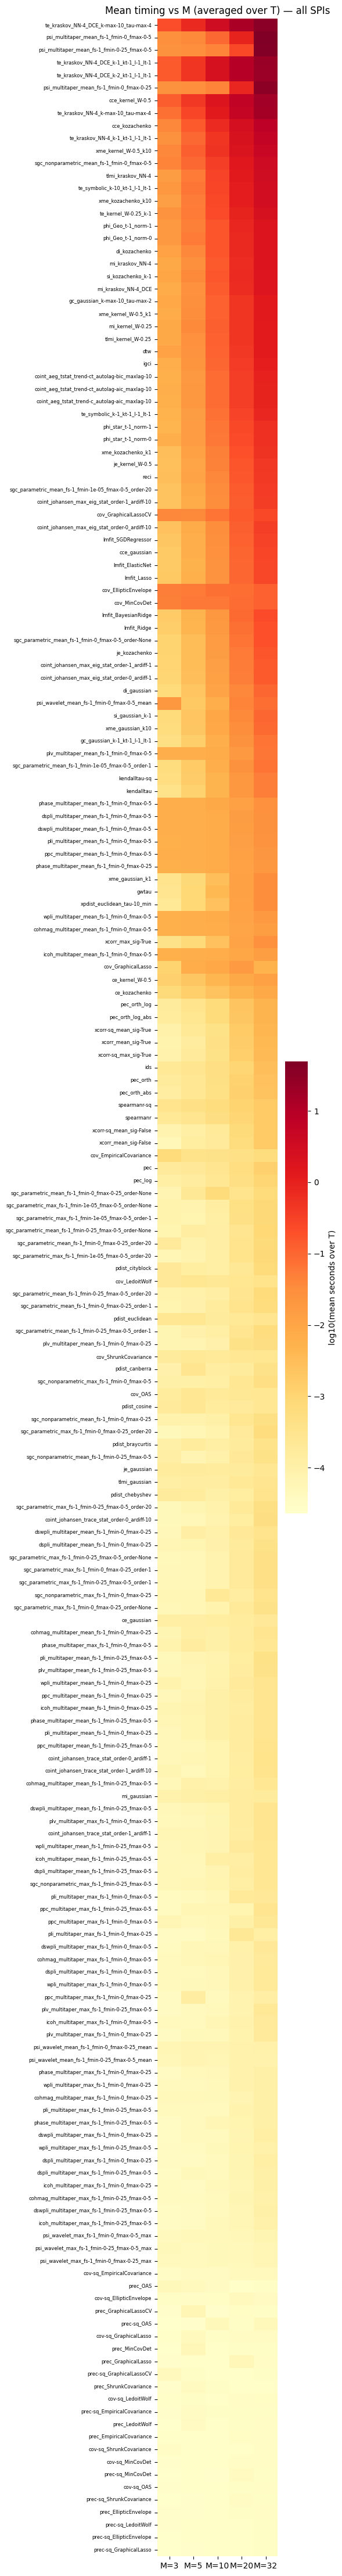

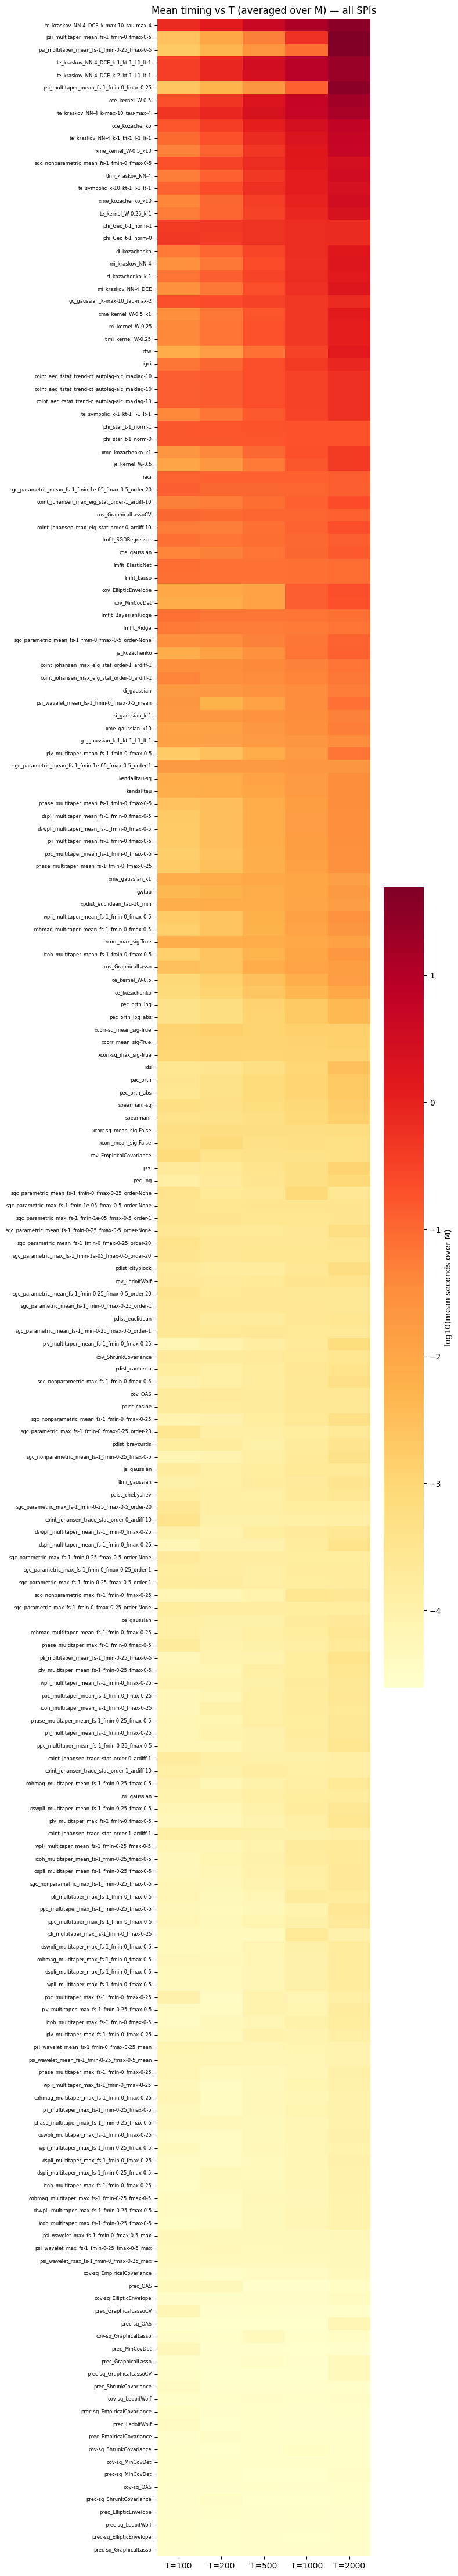

In [8]:
# Two heatmaps: timing vs M (averaged over T) and timing vs T (averaged over M)
# All SPIs, sorted by total mean time descending

all_spis = summary.index.tolist()  # sorted by mean_s desc

# --- M heatmap: mean over T for each M ---
pivot_M = dff.pivot_table(index="spi", columns="M", values="seconds", aggfunc="mean")
pivot_M = pivot_M.loc[all_spis]

fig, ax = plt.subplots(figsize=(6, max(6, len(all_spis) * 0.22)), dpi=100)
sns.heatmap(np.log10(pivot_M.values + 1e-6),
            xticklabels=[f"M={c}" for c in pivot_M.columns],
            yticklabels=pivot_M.index,
            cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "log10(mean seconds over T)"})
ax.set_title("Mean timing vs M (averaged over T) — all SPIs")
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

# --- T heatmap: mean over M for each T ---
pivot_T = dff.pivot_table(index="spi", columns="T", values="seconds", aggfunc="mean")
pivot_T = pivot_T.loc[all_spis]

fig, ax = plt.subplots(figsize=(8, max(6, len(all_spis) * 0.22)), dpi=100)
sns.heatmap(np.log10(pivot_T.values + 1e-6),
            xticklabels=[f"T={c}" for c in pivot_T.columns],
            yticklabels=pivot_T.index,
            cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "log10(mean seconds over M)"})
ax.set_title("Mean timing vs T (averaged over M) — all SPIs")
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

## Empirical complexity estimation

Fit $\log t = \log a + \alpha \log M + \beta \log T$ per SPI via OLS.

$\alpha$ = exponent in M (channels), $\beta$ = exponent in T (time steps).

In [9]:
def fit_complexity(group: pd.DataFrame) -> pd.Series:
    """Fit log(t) = log(a) + alpha*log(M) + beta*log(T) via OLS."""
    valid = group[group["seconds"] > 0].copy()
    if len(valid) < 3:
        return pd.Series({"alpha": np.nan, "beta": np.nan, "log_a": np.nan, "r2": np.nan})
    log_t = np.log(valid["seconds"].values)
    log_M = np.log(valid["M"].values.astype(float))
    log_T = np.log(valid["T"].values.astype(float))
    X = np.column_stack([np.ones(len(valid)), log_M, log_T])
    # OLS
    coef, residuals, rank, sv = np.linalg.lstsq(X, log_t, rcond=None)
    log_a, alpha, beta = coef
    ss_res = np.sum((log_t - X @ coef) ** 2)
    ss_tot = np.sum((log_t - log_t.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return pd.Series({"alpha": alpha, "beta": beta, "log_a": log_a, "r2": r2})

complexity = dff.groupby("spi").apply(fit_complexity).reset_index()
# complexity["family"] = complexity["spi"].apply(get_family)
complexity = complexity.sort_values("alpha", ascending=False)

print("Complexity exponents (alpha=M exponent, beta=T exponent, r2=fit quality)")
# display(complexity[["spi", "family", "alpha", "beta", "r2"]].head(30))
display(complexity[["spi", "alpha", "beta", "r2"]].head(30))

Complexity exponents (alpha=M exponent, beta=T exponent, r2=fit quality)


/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_14194/2857622372.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  complexity = dff.groupby("spi").apply(fit_complexity).reset_index()


,spi,alpha,beta,r2
182,tlmi_kraskov_NN-4,2.207601,1.323174,0.997407
76,mi_kraskov_NN-4,2.202217,1.323149,0.997439
77,mi_kraskov_NN-4_DCE,2.201845,1.328194,0.998123
176,te_kraskov_NN-4_k-1_kt-1_l-1_lt-1,2.195581,1.302779,0.996972
200,xme_kozachenko_k10,2.192914,1.368018,0.997233
177,te_kraskov_NN-4_k-max-10_tau-max-4,2.186273,1.074867,0.994504
2,cce_kozachenko,2.168632,1.199987,0.997787
169,si_kozachenko_k-1,2.145245,1.011640,0.998528
165,sgc_parametric_mean_fs-1_fmin-0_fmax-0-5_order...,2.141153,0.290343,0.991135
14,coint_aeg_tstat_trend-ct_autolag-bic_maxlag-10,2.141060,0.475427,0.994429


KeyError: 'family'

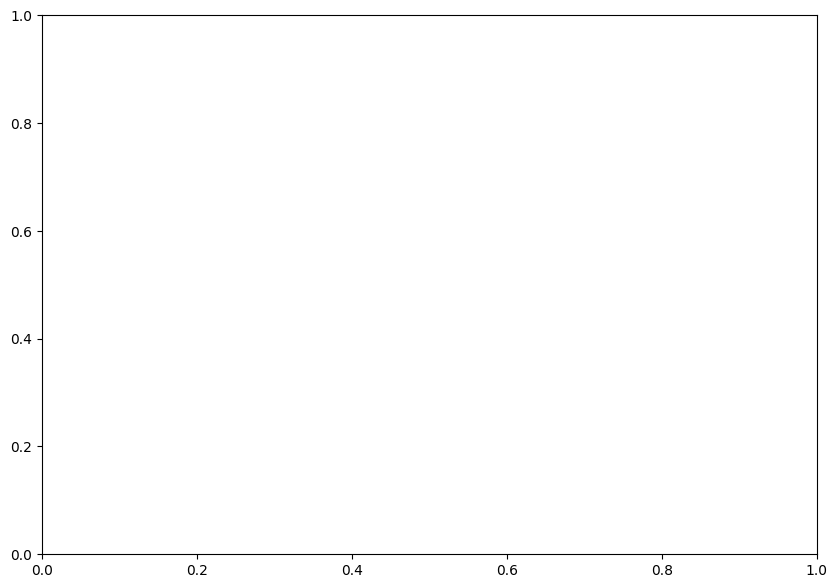

In [10]:
# Scatter: alpha vs beta, colored by family
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
valid_cx = complexity.dropna(subset=["alpha", "beta"])
for fam, grp in valid_cx.groupby("family"):
    ax.scatter(grp["beta"], grp["alpha"], label=fam, s=40, alpha=0.7)
ax.set_xlabel("beta (T exponent)")
ax.set_ylabel("alpha (M exponent)")
ax.set_title("Empirical complexity exponents per SPI")
ax.legend(title="Family", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.axhline(2, color="gray", ls="--", lw=0.5, label="O(M^2)")
ax.axvline(1, color="gray", ls="--", lw=0.5, label="O(T)")
plt.tight_layout()
plt.show()

## Scaling curves for selected SPIs

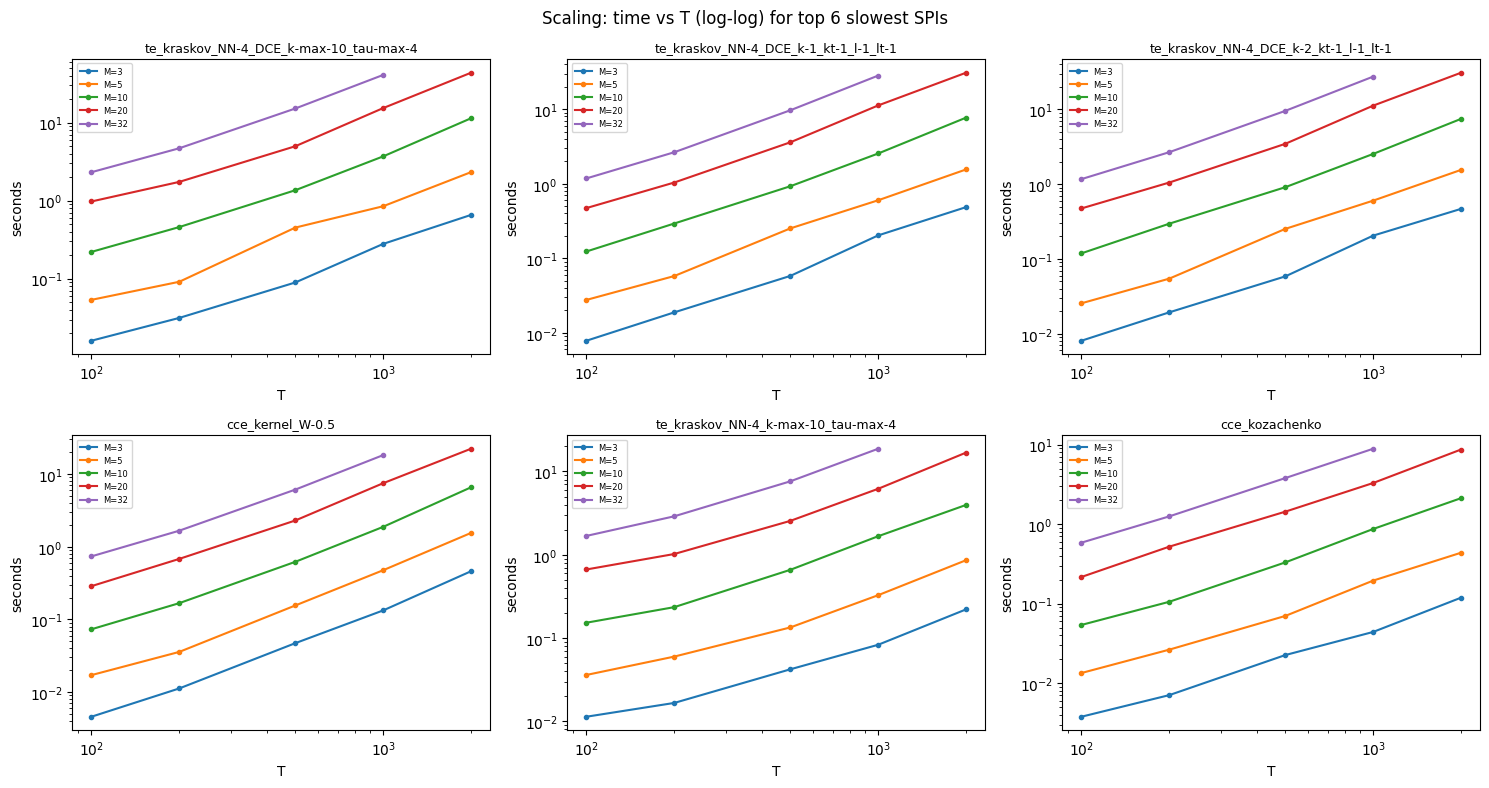

In [ ]:
# Pick top 6 slowest SPIs and plot time vs T for each M
plot_spis = summary.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=100)
for ax, spi_name in zip(axes.flat, plot_spis):
    sub = dff[dff["spi"] == spi_name]
    for M_val, grp in sub.groupby("M"):
        grp_sorted = grp.sort_values("T")
        ax.plot(grp_sorted["T"], grp_sorted["seconds"], "o-", label=f"M={M_val}", markersize=3)
    ax.set_xlabel("T")
    ax.set_ylabel("seconds")
    ax.set_title(spi_name, fontsize=9)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=6)
plt.suptitle("Scaling: time vs T (log-log) for top 6 slowest SPIs")
plt.tight_layout()
plt.show()

## Total time per (M, T) combo

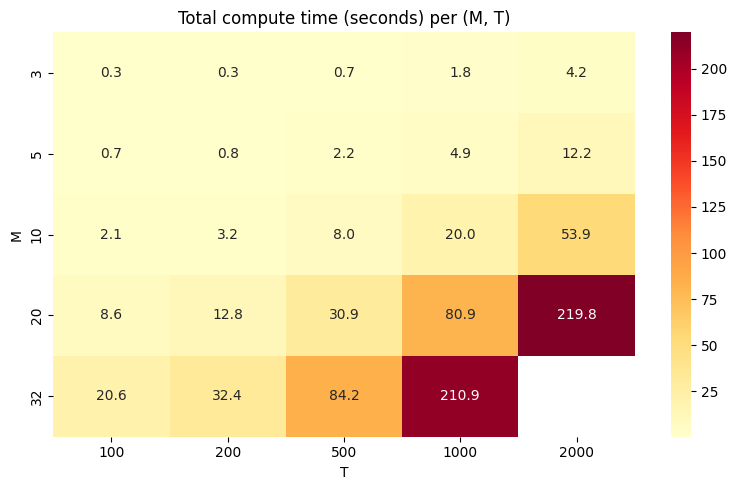


Estimated wall-clock for full grid:
  Total: 817s = 13.6min


In [ ]:
# Total compute time per (M, T) — useful for estimating wall-clock for a full run
combo_totals = dff.groupby(["M", "T"])["seconds"].sum().reset_index()
pivot_total = combo_totals.pivot(index="M", columns="T", values="seconds")

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
sns.heatmap(pivot_total, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Total compute time (seconds) per (M, T)")
plt.tight_layout()
plt.show()

print("\nEstimated wall-clock for full grid:")
print(f"  Total: {combo_totals['seconds'].sum():.0f}s = {combo_totals['seconds'].sum()/60:.1f}min")

## Candidate SPIs to drop: DCE / psi / phi / kernel / coint

Analysis of cost vs. information content for candidate-to-drop groups.

In [16]:
import re

# ── Define candidate groups ────────────────────────────────────────────────────
# For each group: (label, match_fn, rationale)
CANDIDATE_GROUPS = {
    "DCE": (
        lambda s: "DCE" in s,
        "Dynamic Correlation Exclusion variants of kraskov MI/TE.\n"
        "Corrects for autocorrelation bias; non-DCE counterparts already present.\n"
        "Unique info: correction for strongly autocorrelated series."
    ),
    "psi": (
        lambda s: s.startswith("psi_"),
        "Phase Slope Index (spectral + wavelet).\n"
        "Directed measure of frequency-domain coupling via phase gradient.\n"
        "Unique info: frequency-resolved directionality (distinct from GC/TE)."
    ),
    "phi": (
        lambda s: s.startswith("phi_"),
        "Integrated Information (phi_star, phi_Geo) — both normalised & unnormalised.\n"
        "Measures synergistic/integrated information across the whole MTS.\n"
        "Unique info: whole-system integration, not captured by bivariate SPIs."
    ),
    "kernel": (
        lambda s: "kernel" in s,
        "Kernel-density estimators for entropy/MI/TE (je_, ce_, cce_, xme_, te_).\n"
        "Non-parametric alternative to kraskov (NN-based) and gaussian.\n"
        "Unique info: limited — mostly redundant with kraskov for smooth densities."
    ),
    "coint": (
        lambda s: s.startswith("coint_"),
        "Cointegration tests: Johansen (4 variants × 2 orders) + AEG (3 variants).\n"
        "Tests for long-run equilibrium between pairs.\n"
        "Unique info: long-memory coupling not captured by correlation/MI/TE."
    ),
}

all_spis_set = set(summary.index)

group_stats = []
for group, (match_fn, rationale) in CANDIDATE_GROUPS.items():
    members = [s for s in all_spis_set if match_fn(s)]
    if not members:
        continue
    sub = summary.loc[members]
    n = len(members)
    total_s = sub["total_s"].sum()
    mean_s  = sub["mean_s"].mean()
    max_s   = sub["mean_s"].max()
    # fraction of total benchmark time
    frac = total_s / summary["total_s"].sum() * 100
    group_stats.append({
        "group": group,
        "n_spis": n,
        "total_s_all_combos": round(total_s, 1),
        "mean_s_per_combo": round(mean_s, 3),
        "max_mean_s": round(max_s, 3),
        "pct_of_total": round(frac, 2),
        "rationale": rationale,
    })

stats_df = pd.DataFrame(group_stats).set_index("group")
print("Cost summary for candidate groups (across all computed (M,T) combos):")
display(stats_df.drop(columns="rationale").sort_values("pct_of_total", ascending=False))

print()
for group, row in stats_df.iterrows():
    print(f"── {group} ({row['n_spis']} SPIs, {row['pct_of_total']:.1f}% of total time) ──")
    print(f"   {row['rationale']}")
    print()

Cost summary for candidate groups (across all computed (M,T) combos):


,n_spis,total_s_all_combos,mean_s_per_combo,max_mean_s,pct_of_total
group,,,,,
DCE,4,71.4,1.116,1.815,41.77
kernel,8,23.9,0.187,0.864,13.99
phi,4,10.0,0.156,0.238,5.84
coint,11,5.6,0.032,0.089,3.30
psi,9,2.3,0.016,0.088,1.35



── DCE (4 SPIs, 41.8% of total time) ──
   Dynamic Correlation Exclusion variants of kraskov MI/TE.
Corrects for autocorrelation bias; non-DCE counterparts already present.
Unique info: correction for strongly autocorrelated series.

── psi (9 SPIs, 1.4% of total time) ──
   Phase Slope Index (spectral + wavelet).
Directed measure of frequency-domain coupling via phase gradient.
Unique info: frequency-resolved directionality (distinct from GC/TE).

── phi (4 SPIs, 5.8% of total time) ──
   Integrated Information (phi_star, phi_Geo) — both normalised & unnormalised.
Measures synergistic/integrated information across the whole MTS.
Unique info: whole-system integration, not captured by bivariate SPIs.

── kernel (8 SPIs, 14.0% of total time) ──
   Kernel-density estimators for entropy/MI/TE (je_, ce_, cce_, xme_, te_).
Non-parametric alternative to kraskov (NN-based) and gaussian.
Unique info: limited — mostly redundant with kraskov for smooth densities.

── coint (11 SPIs, 3.3% of tota

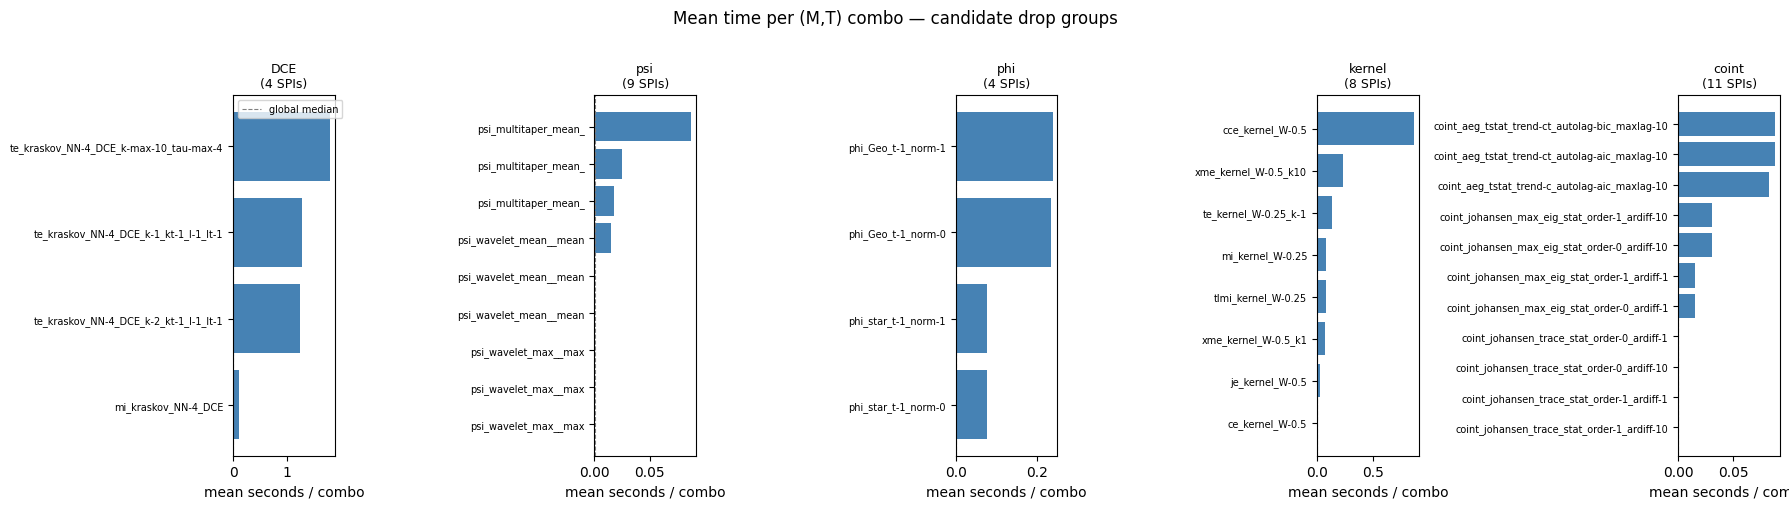

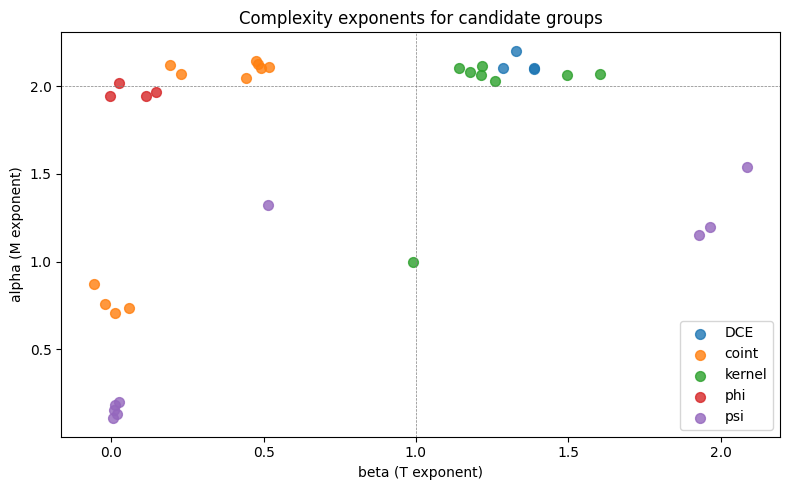

In [17]:
# ── Per-SPI breakdown within each group ───────────────────────────────────────
fig, axes = plt.subplots(1, len(CANDIDATE_GROUPS), figsize=(18, 5), dpi=100)

for ax, (group, (match_fn, _)) in zip(axes, CANDIDATE_GROUPS.items()):
    members = sorted([s for s in all_spis_set if match_fn(s)],
                     key=lambda s: summary.loc[s, "mean_s"], reverse=True)
    if not members:
        ax.set_visible(False)
        continue
    vals = summary.loc[members, "mean_s"].values
    short_labels = [re.sub(r'(fmin-\d+[-\d]*_fmax-\d+[-\d]*|_fs-\d+)', '', s) for s in members]
    ax.barh(range(len(members)), vals, color="steelblue")
    ax.set_yticks(range(len(members)))
    ax.set_yticklabels(short_labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("mean seconds / combo")
    ax.set_title(f"{group}\n({len(members)} SPIs)", fontsize=9)
    ax.axvline(summary["mean_s"].median(), color="gray", ls="--", lw=0.8, label="global median")

axes[0].legend(fontsize=7)
plt.suptitle("Mean time per (M,T) combo — candidate drop groups", y=1.01)
plt.tight_layout()
plt.show()

# ── Scaling: does cost grow fast with M or T? ─────────────────────────────────
cx_sub = complexity[complexity["spi"].apply(
    lambda s: any(fn(s) for fn, _ in CANDIDATE_GROUPS.values())
)].copy()
cx_sub["group"] = cx_sub["spi"].apply(
    lambda s: next((g for g, (fn, _) in CANDIDATE_GROUPS.items() if fn(s)), "other")
)

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
for grp, sub in cx_sub.groupby("group"):
    ax.scatter(sub["beta"], sub["alpha"], label=grp, s=50, alpha=0.8)
ax.set_xlabel("beta (T exponent)")
ax.set_ylabel("alpha (M exponent)")
ax.set_title("Complexity exponents for candidate groups")
ax.axhline(2, color="gray", ls="--", lw=0.5)
ax.axvline(1, color="gray", ls="--", lw=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## EEML context evaluation: keep / drop / reduce

Generator: **VAR(1) motifs** (chain/fork/collider), M=5, T=1000, 1000 instances.
Dynamics: linear, Gaussian iid noise, α ∈ [0.5, 0.95], ρ_nuisance=0.8.

Key question for each group: does it add discriminative information *beyond* cheaper counterparts, given this specific generative model?

In [ ]:
# ── EEML-context assessment ───────────────────────────────────────────────────
# VAR(1), linear Gaussian, M=5, T=1000, motif classification (chain/fork/collider)

EEML_ASSESSMENT = {
    "DCE": {
        "cost_pct": 41.8,
        "verdict": "REDUCE",
        "reasoning": (
            "DCE corrects kraskov estimators for autocorrelation bias. "
            "With ρ_nuisance=0.8 and α ∈ [0.5,0.95], signals ARE autocorrelated, "
            "so DCE is principled. However:\n"
            "  • mi_kraskov_DCE: MI is undirected — DCE correction affects magnitude "
            "but chain/fork/collider differ in *direction*, not MI magnitude. "
            "Non-DCE kraskov MI already present → DROP mi_kraskov_DCE.\n"
            "  • te_kraskov_DCE_k-max-10_tau-max-4: auto-embed TE with DCE is the "
            "single most expensive SPI (>1s/combo). For VAR(1), k=1 is sufficient "
            "by model definition. k_max=10 wastes AIS grid search on a model "
            "where embedding=1 will always win → DROP auto-embed DCE TE.\n"
            "  • te_kraskov_DCE_k-1/k-2: fixed-embedding DCE TE is moderately "
            "expensive but genuinely distinct from non-DCE TE for autocorrelated "
            "VAR — KEEP."
        ),
        "drop_spis": ["mi_kraskov_NN-4_DCE", "te_kraskov_NN-4_DCE_k-max-10_tau-max-4"],
        "keep_spis": ["te_kraskov_NN-4_DCE_k-1_kt-1_l-1_lt-1", "te_kraskov_NN-4_DCE_k-2_kt-1_l-1_lt-1"],
        "est_saving_pct": "~30% of total (dropping the 2 most expensive DCE SPIs)",
    },
    "psi": {
        "cost_pct": 1.4,
        "verdict": "KEEP",
        "reasoning": (
            "Only 1.4% of total time. PSI is the only frequency-resolved "
            "directionality measure in the set — distinct from time-domain TE/GC. "
            "For VAR(1) motifs, PSI in the [0, 0.5] band should capture directed "
            "coupling. Cost is negligible; keep all 9 variants."
        ),
        "drop_spis": [],
        "keep_spis": ["all"],
        "est_saving_pct": "0%",
    },
    "phi": {
        "cost_pct": 5.8,
        "verdict": "KEEP phi_star / RECONSIDER phi_Geo",
        "reasoning": (
            "phi measures whole-system synergistic integration — genuinely not "
            "captured by any bivariate SPI. For M=5 motifs:\n"
            "  • Chain: low phi (information just passes through).\n"
            "  • Fork: moderate phi (common cause creates correlations).\n"
            "  • Collider: high phi (convergent causation creates synergy).\n"
            "phi_star (cheap, ~0.05s) → KEEP.\n"
            "phi_Geo (expensive, ~0.2s, and known to be numerically unstable for "
            "small M) → consider dropping, but 5.8% total cost is tolerable on cluster."
        ),
        "drop_spis": [],  # phi_Geo_norm-0/1 if cost is a concern
        "keep_spis": ["phi_star_t-1_norm-0", "phi_star_t-1_norm-1", "phi_Geo_t-1_norm-0", "phi_Geo_t-1_norm-1"],
        "est_saving_pct": "0–3% (only if dropping phi_Geo)",
    },
    "kernel": {
        "cost_pct": 14.0,
        "verdict": "DROP",
        "reasoning": (
            "VAR(1) with Gaussian iid noise → data is approximately multivariate "
            "Gaussian. For Gaussian data:\n"
            "  • Gaussian estimators are exact (maximum likelihood).\n"
            "  • Kraskov (NN-based) is consistent but slower.\n"
            "  • Kernel estimators are the worst of both worlds: slower than "
            "gaussian, less efficient than kraskov for non-Gaussian data.\n"
            "cce_kernel (0.6s/combo) and xme_kernel (0.1s) dominate the cost. "
            "All information captured by kernel SPIs is better captured by "
            "gaussian or kraskov counterparts already in the config. DROP all."
        ),
        "drop_spis": ["all kernel SPIs (8 total)"],
        "keep_spis": [],
        "est_saving_pct": "~14% of total",
    },
    "coint": {
        "cost_pct": 3.3,
        "verdict": "DROP",
        "reasoning": (
            "Cointegration (Johansen, AEG) tests for unit-root processes with "
            "long-run equilibria. VAR(1) with α ∈ [0.5, 0.95] are STATIONARY "
            "(spectral radius < 1 by construction), not cointegrated. "
            "Applying these tests to stationary processes produces uninformative "
            "test statistics — not meaningfully different across chain/fork/collider. "
            "DROP all 11."
        ),
        "drop_spis": ["all coint SPIs (11 total)"],
        "keep_spis": [],
        "est_saving_pct": "~3.3% of total",
    },
}

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for group, info in EEML_ASSESSMENT.items():
    rows.append({
        "group": group,
        "cost_%": info["cost_pct"],
        "verdict": info["verdict"],
        "n_drop": len(info["drop_spis"]) if info["drop_spis"] != ["all kernel SPIs (8 total)"] and info["drop_spis"] != ["all coint SPIs (11 total)"] else "all",
        "est_saving": info["est_saving_pct"],
    })
display(pd.DataFrame(rows).set_index("group"))

print("\n── Detailed reasoning ──────────────────────────────────────────────────")
for group, info in EEML_ASSESSMENT.items():
    print(f"\n[{info['verdict']}] {group} ({info['cost_pct']}% of total)")
    for line in info["reasoning"].split("\n"):
        print(f"  {line}")